## Drug Classification Project

In [2]:
pip install kagglehub

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]━ 2/4 [kagglesdk]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC


In [ ]:
# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)/home/huseyin/.cache/kagglehub/datasets/prathamtripathi/drug-classification/versions/1/drug200.csv

Path to dataset files: /home/huseyin/.cache/kagglehub/datasets/prathamtripathi/drug-classification/versions/1


In [11]:
data = pd.read_csv("drug200.csv")
data.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,DrugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,DrugY
9,43,M,LOW,NORMAL,19.368,DrugY


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [13]:
data["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

In [15]:
X = data.drop("Drug", axis=1)
y = data["Drug"]

In [18]:
print("Features:")
print(X.head(7))

Features:
   Age Sex      BP Cholesterol  Na_to_K
0   23   F    HIGH        HIGH   25.355
1   47   M     LOW        HIGH   13.093
2   47   M     LOW        HIGH   10.114
3   28   F  NORMAL        HIGH    7.798
4   61   F     LOW        HIGH   18.043
5   22   F  NORMAL        HIGH    8.607
6   49   F  NORMAL        HIGH   16.275


In [ ]:
print("Target:")
print(y.head())


Target:
0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object


In [19]:
label_encoders = {}

categorical_columns = ["Sex", "BP", "Cholesterol"]

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

print(X.head())

   Age  Sex  BP  Cholesterol  Na_to_K
0   23    0   0            0   25.355
1   47    1   1            0   13.093
2   47    1   1            0   10.114
3   28    0   2            0    7.798
4   61    0   1            0   18.043


In [20]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Original target values:")
print(y.head())

print("Encoded target values:")
print(y_encoded[:10])

print("Drug classes:")
print(target_encoder.classes_)

Original target values:
0    DrugY
1    drugC
2    drugC
3    drugX
4    DrugY
Name: Drug, dtype: object
Encoded target values:
[0 3 3 4 0 4 0 3 0 0]
Drug classes:
['DrugY' 'drugA' 'drugB' 'drugC' 'drugX']


### Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (160, 5)
Testing data shape: (40, 5)


In [22]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

### Prediction

In [23]:
y_pred = model.predict(X_test)

print("Predicted:")
print(y_pred)

print("Actual:")
print(y_test)

Predicted:
[0 1 0 0 4 4 4 4 3 3 0 1 0 4 1 0 0 0 4 0 0 1 0 4 0 0 0 0 1 4 0 0 0 0 2 2 4
 2 3 4]
Actual:
[0 1 0 0 4 4 4 4 3 3 0 1 0 4 1 0 0 0 4 0 0 1 0 4 0 0 0 0 1 4 0 4 0 0 2 2 4
 2 3 4]


In [24]:
predicted_drugs = target_encoder.inverse_transform(y_pred)
actual_drugs = target_encoder.inverse_transform(y_test)

print("Predicted drug names:")
print(predicted_drugs)

print("Actual drug names:")
print(actual_drugs)

Predicted drug names:
['DrugY' 'drugA' 'DrugY' 'DrugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC'
 'drugC' 'DrugY' 'drugA' 'DrugY' 'drugX' 'drugA' 'DrugY' 'DrugY' 'DrugY'
 'drugX' 'DrugY' 'DrugY' 'drugA' 'DrugY' 'drugX' 'DrugY' 'DrugY' 'DrugY'
 'DrugY' 'drugA' 'drugX' 'DrugY' 'DrugY' 'DrugY' 'DrugY' 'drugB' 'drugB'
 'drugX' 'drugB' 'drugC' 'drugX']
Actual drug names:
['DrugY' 'drugA' 'DrugY' 'DrugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC'
 'drugC' 'DrugY' 'drugA' 'DrugY' 'drugX' 'drugA' 'DrugY' 'DrugY' 'DrugY'
 'drugX' 'DrugY' 'DrugY' 'drugA' 'DrugY' 'drugX' 'DrugY' 'DrugY' 'DrugY'
 'DrugY' 'drugA' 'drugX' 'DrugY' 'drugX' 'DrugY' 'DrugY' 'drugB' 'drugB'
 'drugX' 'drugB' 'drugC' 'drugX']


### Evaluation

In [25]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.975


In [26]:
print(classification_report(
    y_test,
    y_pred,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



In [27]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[18  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  3  0]
 [ 1  0  0  0 10]]


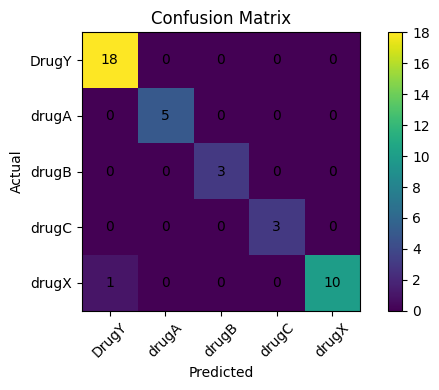

In [28]:
plt.figure(figsize=(6, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(target_encoder.classes_)), target_encoder.classes_, rotation=45)
plt.yticks(range(len(target_encoder.classes_)), target_encoder.classes_)
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [29]:
new_patient = pd.DataFrame({
    "Age": [35],
    "Sex": ["M"],
    "BP": ["HIGH"],
    "Cholesterol": ["NORMAL"],
    "Na_to_K": [15.5]
})

In [30]:
for column in categorical_columns:
    new_patient[column] = label_encoders[column].transform(new_patient[column])

prediction = model.predict(new_patient)

predicted_drug = target_encoder.inverse_transform(prediction)

print("Predicted drug:", predicted_drug[0])

Predicted drug: DrugY


In [31]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.975


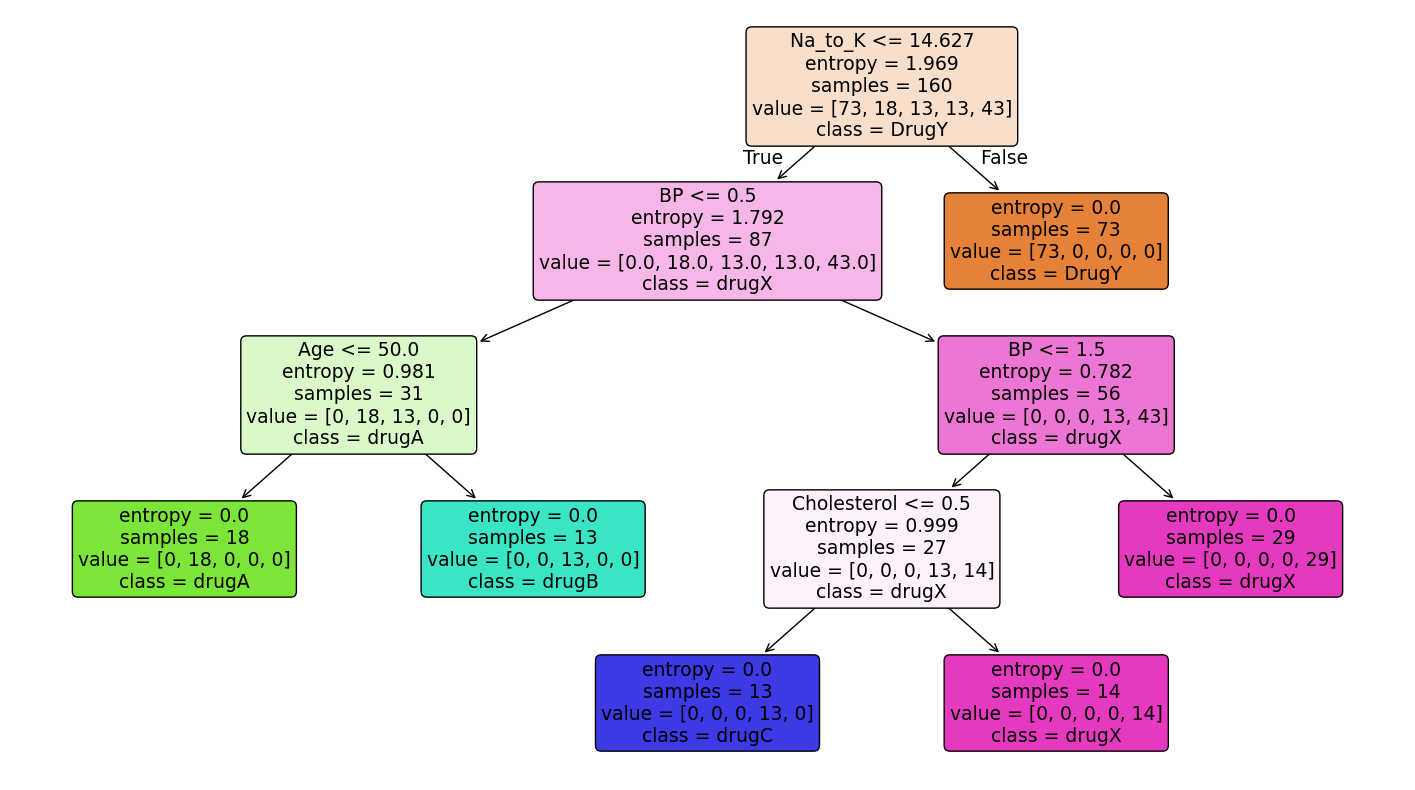

In [34]:
plt.figure(figsize=(18, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=target_encoder.classes_,
    filled=True,
    rounded=True
)

plt.show()

In [36]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC()
}

In [37]:
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name)
    print("Accuracy:", accuracy)
    print("-" * 30)

Decision Tree
Accuracy: 0.975
------------------------------
Random Forest
Accuracy: 0.975
------------------------------
KNN
Accuracy: 0.75
------------------------------
Logistic Regression
Accuracy: 0.975
------------------------------
SVM
Accuracy: 0.7
------------------------------


/home/huseyin/jupyter_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
X = data.drop("Drug", axis=1)
y = data["Drug"]

X = pd.get_dummies(X, columns=["Sex", "BP", "Cholesterol"])

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [39]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Accuracy: 0.975
              precision    recall  f1-score   support

       DrugY       0.95      1.00      0.97        18
       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40

